<a href="https://colab.research.google.com/github/DangLeUyen/Computer-Vision-From-Scratch/blob/main/ViT_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn


In [41]:
# Transformation from PIL to Tensor format
transform_data = transforms.Compose([
    transforms.ToTensor()
])

In [42]:
# Load dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform_data, download=True)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform_data, download=True)

In [43]:
# Define variables
NUM_CLASSES = len(train_dataset.classes)
NUM_CHANNELS = 1
BATCH_SIZE = 64
IMG_SIZE = 28
PATCH_SIZE = 7
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE)**2
EMBEDDING_DIM = 64
ATTENTION_HEADS = 4
TRANSFORMER_BLOCKS = 4
MLP_HIDDEN_NODES = 128
LEARNING_RATE = 0.001
EPOCHS = 5

In [44]:
# Define dataset batches
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)


## PART 1: Patch Embedding

In [45]:
class PatchEmbedding(torch.nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.patch_embed = nn.Conv2d(in_channels=NUM_CHANNELS,
                                 out_channels=EMBEDDING_DIM,
                                 kernel_size=PATCH_SIZE,
                                 stride=PATCH_SIZE)

  def forward(self, x):
    # Patch_embedding
    x = self.patch_embed(x)
    # Flattening
    x = x.flatten(2)
    # Position Embedding
    x = x.transpose(1,2)

    return x


## PART 2: Transformer Encoder

In [46]:
class TransformerEncoder(torch.nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(EMBEDDING_DIM)
    self.layer_norm2 = nn.LayerNorm(EMBEDDING_DIM)
    self.multihead_attention = nn.MultiheadAttention(EMBEDDING_DIM, ATTENTION_HEADS, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(EMBEDDING_DIM, MLP_HIDDEN_NODES),
        nn.GELU(),
        nn.Linear(MLP_HIDDEN_NODES, EMBEDDING_DIM)
    )

  def forward(self, x):

    # Residual 1
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multihead_attention(x, x, x)[0]
    x = x + residual1

    # Residual 2
    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x

## PART 3: MLP_Head

In [47]:
class MLP_Head(torch.nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.layer_norm = nn.LayerNorm(EMBEDDING_DIM)
    self.mlp_head = nn.Linear(EMBEDDING_DIM, NUM_CLASSES)

  def forward(self, x):
    x = self.layer_norm(x)
    x = self.mlp_head(x)

    return x

## PART 4: Transformer Class

In [48]:
class VisionTransformer(torch.nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    # Class token
    self.cls_token = nn.Parameter(torch.randn(1, 1, EMBEDDING_DIM))
    # Position Embedding
    self.postion_embedding = nn.Parameter(torch.randn(1, NUM_PATCHES + 1, EMBEDDING_DIM))

    self.transformer_blocks = nn.Sequential(
        *[TransformerEncoder() for _ in range(TRANSFORMER_BLOCKS)]
        )

    self.mlp_head = MLP_Head()

  def forward(self, x):
    x = self.patch_embedding(x)
    class_token = self.cls_token.expand(x.size(0), -1, -1)
    x = torch.cat([class_token, x], dim=1)
    x = x + self.postion_embedding
    x = self.transformer_blocks(x)
    x = x[:, 0]
    x = self.mlp_head(x)

    return x

## Training

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

In [50]:
# Training loop
for epoch in range(EPOCHS):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    accuracy = 100* correct / labels.size(0)
    correct_epoch += correct
    total_epoch += labels.size(0)

    if batch_idx % 100 == 0:
      print(f"Batch: {batch_idx+1:3d}, Loss: {loss.item():.4f}, Accuracy: {accuracy} %")

  accuracy_epoch = 100*correct_epoch / total_epoch
  print(f"==> Epoch: {epoch+1}, Total Loss: {total_loss}, Accuracy: {accuracy_epoch}%")


Batch:   1, Loss: 2.4390, Accuracy: 10.9375 %
Batch: 101, Loss: 0.6511, Accuracy: 76.5625 %
Batch: 201, Loss: 0.3591, Accuracy: 90.625 %
Batch: 301, Loss: 0.3177, Accuracy: 90.625 %
Batch: 401, Loss: 0.3950, Accuracy: 87.5 %
Batch: 501, Loss: 0.3201, Accuracy: 89.0625 %
Batch: 601, Loss: 0.2576, Accuracy: 95.3125 %
Batch: 701, Loss: 0.1816, Accuracy: 93.75 %
Batch: 801, Loss: 0.3118, Accuracy: 93.75 %
Batch: 901, Loss: 0.0990, Accuracy: 98.4375 %
==> Epoch: 1, Total Loss: 346.99361653998494, Accuracy: 88.24666666666667%
Batch:   1, Loss: 0.0947, Accuracy: 96.875 %
Batch: 101, Loss: 0.1243, Accuracy: 95.3125 %
Batch: 201, Loss: 0.0488, Accuracy: 100.0 %
Batch: 301, Loss: 0.0402, Accuracy: 100.0 %
Batch: 401, Loss: 0.1289, Accuracy: 98.4375 %
Batch: 501, Loss: 0.3033, Accuracy: 92.1875 %
Batch: 601, Loss: 0.1934, Accuracy: 93.75 %
Batch: 701, Loss: 0.0965, Accuracy: 96.875 %
Batch: 801, Loss: 0.1753, Accuracy: 93.75 %
Batch: 901, Loss: 0.1050, Accuracy: 96.875 %
==> Epoch: 2, Total Loss:

In [51]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in val_loader:
    images,labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    total += labels.size(0)
    correct += (preds == labels).sum().item()

val_acc = 100 * correct / total
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 97.51%


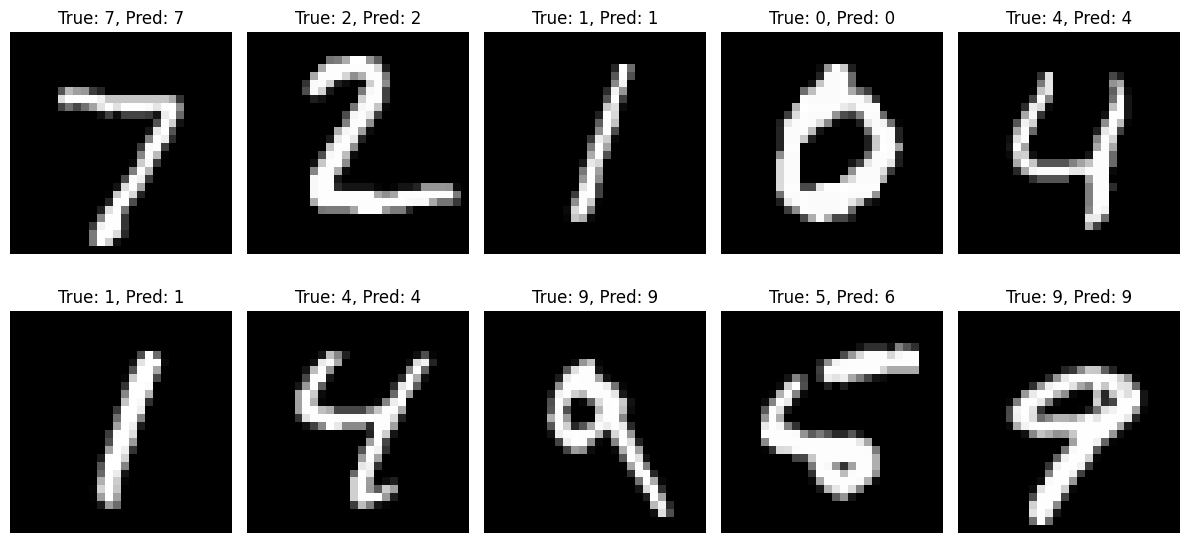

In [52]:
# Plot 10 results

import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1)

# Plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"True: {labels[i].item()}, Pred: {preds[i].item()}")
  plt.axis('off')

plt.tight_layout()
plt.show()